In [15]:
import aotools
import numpy
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image
from tqdm import tqdm, trange, tqdm_notebook
import scipy.signal
import sys,os

In [6]:
data = fits.getdata('tabai5mm.fits')
data[:,:,0:2]=0
array_size=128
padding=2
wavelength=833e-3 #(this is the wavelength data was taken at in microns)
diameter=5e-3 #(pupil diameter in m)
psf_size=array_size*padding
j=0+1j
print(data.shape)

(50, 808, 65)


In [7]:
# check how long it takes to do this for first 100 timepoints
z=aotools.zernikeArray(66,array_size)
z=z[1:] #zernikearray creates an array with piston - our data does not have piston in it, so remove this
frames = data.shape[0]*100
#reshape into a 65 x (array_size*array_size) array
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
psfs = numpy.zeros((frames, psf_size, psf_size))
wfs = numpy.zeros((frames, array_size, array_size))
o=0
for n in range(0,50):
    for m in range(0,100):
        
        #print(n,m)
        dat = data[n,m,:]
        #print(dat.shape)
        
        
        

        #convert to radians!
        wf = numpy.dot(dat,zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[o]=wf
        complex_phase = numpy.exp(j*wf)
        psf_size=array_size*padding
        padded_pupil = numpy.zeros((psf_size, psf_size), dtype=numpy.complex64)
        padded_pupil[:array_size, :array_size] = complex_phase
        
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[o] = psf

        o=o+1




#get the eye data
#calc all psfs
#potentially save array of psfs as a .npy?

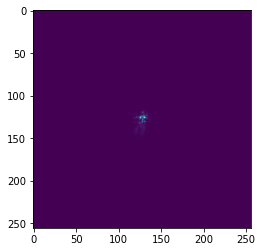

In [8]:
plt.imshow(psfs[0])

In [9]:
eedata=[]


for n in range(len(psfs)):
    e=aotools.encircled_energy(psfs[n], fraction=0.5, center=None, eeDiameter=True)
    eedata.append(e)

In [10]:
print(eedata)

[10.520547945205479, 10.520547945205479, 10.019569471624266, 10.019569471624266, 9.518590998043052, 10.520547945205479, 10.270058708414872, 10.270058708414872, 10.520547945205479, 11.021526418786692, 10.520547945205479, 10.771037181996086, 10.520547945205479, 10.019569471624266, 10.771037181996086, 10.520547945205479, 10.771037181996086, 10.019569471624266, 10.270058708414872, 11.021526418786692, 10.019569471624266, 10.771037181996086, 11.021526418786692, 11.272015655577299, 11.272015655577299, 11.522504892367905, 11.272015655577299, 11.522504892367905, 11.772994129158512, 12.023483365949119, 12.023483365949119, 11.772994129158512, 12.023483365949119, 11.772994129158512, 11.522504892367905, 11.272015655577299, 12.023483365949119, 12.023483365949119, 11.772994129158512, 11.772994129158512, 11.772994129158512, 12.023483365949119, 11.772994129158512, 12.023483365949119, 12.023483365949119, 11.772994129158512, 11.772994129158512, 11.522504892367905, 11.772994129158512, 11.772994129158512, 

In [12]:
print(len(eedata))

5000


Work out what unit this actually is - we could ask the aotools guys?

ERICA images

In [17]:
imfolder='C:/Users/pflaw/Documents/GitHub/ERICA/eccentricities'
im1_=Image.open(os.path.join(imfolder,os.listdir(imfolder)[0]))
im1=numpy.asarray(im1_)
w,h =im1.shape
imarray=numpy.zeros((5,w,h))


#make sure you match the 
files=os.listdir(imfolder)

for n in range(5):
    filename=files[n]
    im = Image.open(os.path.join(imfolder,filename))
    image=numpy.asarray(im)
    imarray[n]=image
    


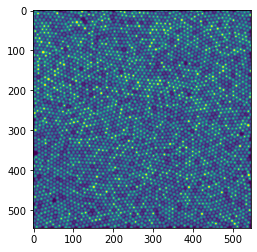

In [19]:
plt.imshow(imarray[1])

In [21]:
convarray=numpy.zeros((5,frames,w,h))

check the pixel scale and padding here

In [ ]:
l=0
for n in range(5): 
    image=imarray[n]
    for m in range(frames):
        convolution = scipy.signal.convolve2d(image, psfs[m], mode='same',boundary='wrap')
        convarray[l]=convolution
        l=l+1
        


we now have a big array of images.  Save this as a .npy?

In [ ]:
now calculate the sharpness metrics.  Should end up with a 3x5xframes array

In [27]:
#import ERICA images for 5 eccentricities
#apply all aberrations to all images
#calculate 3x sharpness metrics for all images with all eccentricities

In [11]:
#plot 5x graphs, on each graph 3 sharpness metrics vs encircled energy, colour by sharpness metric.  Compare.